# rxnfp + CatEmb Random/OOS QSPR Regression Scatter Plots

This notebook plots observed-vs-predicted regression scatter plots for the best rxnfp + CatEmb QSPR configurations on random split and OOS split tasks for the Aryl scope and Thiol addition datasets.

Generated figures are separated into random-split seed panels and OOS-split panels for each dataset.


In [1]:
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

ROOT = Path.cwd().resolve()
REPO_ROOT = ROOT.parent if ROOT.name == "notebook" else ROOT
NOTEBOOK_DIR = REPO_ROOT / "notebook"
GEN_DESC_DIR = NOTEBOOK_DIR / "gen_desc"
RESULT_DIR = NOTEBOOK_DIR / "recommend_results" / "rxnfp_catemb_qspr_scatter"
BENCHMARK_DIR = REPO_ROOT / "benchmark_results" / "rxnfp_catemb_qspr"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from catemb import CatEmb

RANDOM_SEED = 42
N_ESTIMATORS = 500
RANDOM_SPLIT_SEEDS = list(range(10))
DEFAULT_CATEMB_MODEL_ROOT = Path(
    "/inspire/hdd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/"
    "global_user/8359-xulicheng/CatEmb/save_model"
)

DATASET_INFO = {
    "aryl": {
        "dataset": "Aryl scope",
        "prefix": "aryl_scope",
        "test_size": 0.2,
    },
    "thiol": {
        "dataset": "Thiol addition",
        "prefix": "thiol_addition",
        "test_size": 475 / 1075,
    },
}

for info in DATASET_INFO.values():
    prefix = info["prefix"]
    info["json_path"] = BENCHMARK_DIR / f"{prefix}_rxnfp_catemb_qspr.json"
    info["random_summary_path"] = BENCHMARK_DIR / f"{prefix}_rxnfp_catemb_random_summary.csv"
    info["oos_summary_path"] = BENCHMARK_DIR / f"{prefix}_rxnfp_catemb_oos_summary.csv"

BENCHMARK_META = {key: json.loads(info["json_path"].read_text()) for key, info in DATASET_INFO.items()}


def resolve_catemb_model_paths(dims):
    paths = {}
    if DEFAULT_CATEMB_MODEL_ROOT.exists():
        subdirs = sorted(path for path in DEFAULT_CATEMB_MODEL_ROOT.iterdir() if path.is_dir())
        for dim in dims:
            matches = [
                path
                for path in subdirs
                if f"dim{dim}" in path.name
                and (path / "best_model.pt").exists()
                and (path / "full_params.npy").exists()
            ]
            if matches:
                paths[dim] = matches[0]
    local_dim32 = REPO_ROOT / "catemb" / "model_path" / "dim32LN"
    if 32 in dims and 32 not in paths and local_dim32.exists():
        paths[32] = local_dim32
    missing = [dim for dim in dims if dim not in paths]
    if missing:
        raise FileNotFoundError(f"Missing CatEmb model paths for dimensions: {missing}")
    return paths

CATEMB_MODEL_PATHS = resolve_catemb_model_paths(
    sorted({dim for meta in BENCHMARK_META.values() for dim in meta["catemb_dims"]})
)


/opt/conda/envs/catemb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def make_model(model_type, n_estimators=N_ESTIMATORS):
    if model_type == "ExtraTrees":
        return ExtraTreesRegressor(n_estimators=n_estimators, random_state=RANDOM_SEED, n_jobs=-1)
    if model_type == "Ridge":
        return make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    if model_type == "KernelRidge":
        return make_pipeline(StandardScaler(), KernelRidge(alpha=1.0, kernel="rbf"))
    if model_type == "SVR":
        return make_pipeline(StandardScaler(), SVR(C=10.0, epsilon=0.1))
    raise ValueError(model_type)


def metrics(y_true, y_pred):
    return {
        "r2": float(r2_score(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_true, y_pred))),
    }


def best_random_config(dataset_key):
    info = DATASET_INFO[dataset_key]
    path = info["random_summary_path"]
    df = pd.read_csv(path).sort_values(["r2_mean", "mae_mean"], ascending=[False, True]).reset_index(drop=True)
    cfg = df.iloc[0].to_dict()
    cfg.update({
        "dataset": info["dataset"],
        "test_size": info["test_size"],
        "source_file": str(path),
        "catemb_dim": int(cfg["catemb_dim"]),
    })
    return cfg


def best_oos_config(dataset_key, split_name):
    info = DATASET_INFO[dataset_key]
    path = info["oos_summary_path"]
    df = pd.read_csv(path)
    df = df[df["split"].eq(split_name)].sort_values(["r2", "mae"], ascending=[False, True]).reset_index(drop=True)
    cfg = df.iloc[0].to_dict()
    cfg.update({
        "dataset": info["dataset"],
        "variant": "model_only",
        "source_file": str(path),
        "catemb_dim": int(cfg["catemb_dim"]),
    })
    return cfg


def oos_split_idx_map(dataset_key):
    split_def = BENCHMARK_META[dataset_key]["oos_split_definition"]
    split_idx_map = {"train": [], "substrate_oos": [], "catalyst_oos": [], "substrate_catalyst_oos": []}
    if dataset_key == "aryl":
        df = load_aryl_data()["df"]
        eids = set(split_def["oos_electrophile_ids"])
        nids = set(split_def["oos_nucleophile_ids"])
        ligs = set(split_def["oos_ligand_names"])
        for idx, row in df.iterrows():
            sub = row["electrophile_id"] in eids or row["nucleophile_id"] in nids
            cat = row["ligand_name"] in ligs
            split_idx_map["substrate_catalyst_oos" if sub and cat else "substrate_oos" if sub else "catalyst_oos" if cat else "train"].append(idx)
    else:
        df = load_thiol_data()["df"]
        imines = set(split_def["oos_imine"])
        thiols = set(split_def["oos_thiol"])
        cats = set(split_def["oos_catalysts"])
        for idx, row in df.iterrows():
            sub = row["Imine"] in imines or row["Thiol"] in thiols
            cat = row["Catalyst"] in cats
            split_idx_map["substrate_catalyst_oos" if sub and cat else "substrate_oos" if sub else "catalyst_oos" if cat else "train"].append(idx)
    expected = BENCHMARK_META[dataset_key]["split_idx_sizes"]
    actual = {split: len(idx) for split, idx in split_idx_map.items()}
    if actual != expected:
        raise ValueError(f"OOS split size mismatch for {dataset_key}: {actual} != {expected}")
    return split_idx_map


def build_catemb_repr_map(smiles_list, dim, cache_name, batch_size=128):
    cache_path = GEN_DESC_DIR / cache_name
    unique_smiles = sorted(set(smiles_list))
    if cache_path.exists():
        repr_map = np.load(cache_path, allow_pickle=True).item()
        if set(unique_smiles).issubset(repr_map):
            return repr_map
    catemb = CatEmb(model_path=str(CATEMB_MODEL_PATHS[dim]), device="cpu")
    desc = catemb.gen_desc(unique_smiles, batch_size=batch_size)
    repr_map = {smi: np.asarray(x) for smi, x in zip(unique_smiles, desc)}
    np.save(cache_path, repr_map)
    return repr_map


def stack_repr(repr_map, smiles_list):
    return np.stack([repr_map[smi] for smi in smiles_list], axis=0)


In [3]:
def load_aryl_data():
    df = pd.read_csv(REPO_ROOT / "dataset" / "rxn_data" / "aryl-scope-ligand.csv")
    lig_cat_df = pd.read_csv(REPO_ROOT / "dataset" / "rxn_data" / "ligand_catalyst_map_of_aryl.csv")
    lig_cat_map = dict(zip(lig_cat_df["Ligand"], lig_cat_df["Catalyst"]))
    return {
        "df": df,
        "label": df["yield"].to_numpy(float),
        "ligand": df["ligand_smiles"].to_list(),
        "catalyst": [lig_cat_map[lig] for lig in df["ligand_smiles"]],
        "rxn_wo_cat": [
            f"{e}.{n}>>{p}"
            for e, n, p in zip(df["electrophile_smiles"], df["nucleophile_smiles"], df["product_smiles"])
        ],
    }


def load_thiol_data():
    df = pd.read_csv(REPO_ROOT / "dataset" / "rxn_data" / "NS_acetal_dataset_with_pdt.csv")
    return {
        "df": df,
        "label": df["ΔΔG"].to_numpy(float),
        "catalyst": df["Catalyst"].to_list(),
        "rxn_wo_cat": [
            f"{imine}.{thiol}>>{pdt}"
            for imine, thiol, pdt in zip(df["Imine"], df["Thiol"], df["Product"])
        ],
    }


def build_aryl_features(dim, strategy_name=None):
    data = load_aryl_data()
    rxnfp_map = np.load(GEN_DESC_DIR / "aryl_scope_rxn_smi_wo_lig_rxnfp_map.npy", allow_pickle=True).item()
    rxn_fp = np.asarray([rxnfp_map[smi] for smi in data["rxn_wo_cat"]])
    repr_map = build_catemb_repr_map(
        data["ligand"] + data["catalyst"],
        dim=dim,
        cache_name=f"scatter_aryl_catemb_dim{dim}_repr_map.npy",
    )
    lig_desc = stack_repr(repr_map, data["ligand"])
    if strategy_name == "aryl_scope_rxnfp_plus_catemb_ligand":
        x = np.concatenate([rxn_fp, lig_desc], axis=1)
    else:
        cat_desc = stack_repr(repr_map, data["catalyst"])
        x = np.concatenate([rxn_fp, lig_desc, cat_desc], axis=1)
    return x, data["label"]


def build_thiol_features(dim, strategy_name=None):
    data = load_thiol_data()
    rxnfp_map = np.load(GEN_DESC_DIR / "thiol_add_rxn_smi_wo_cat_rxnfp_map.npy", allow_pickle=True).item()
    rxn_fp = np.asarray([rxnfp_map[smi] for smi in data["rxn_wo_cat"]])
    repr_map = build_catemb_repr_map(
        data["catalyst"],
        dim=dim,
        cache_name=f"scatter_thiol_catemb_dim{dim}_repr_map.npy",
    )
    cat_desc = stack_repr(repr_map, data["catalyst"])
    x = np.concatenate([rxn_fp, cat_desc], axis=1)
    return x, data["label"]


In [4]:
def random_split_predictions(dataset_key, build_features):
    cfg = best_random_config(dataset_key)
    x, y = build_features(cfg["catemb_dim"], cfg["strategy_name"])
    frames = []
    seed_metrics = []
    indices = np.arange(len(y))
    for seed in RANDOM_SPLIT_SEEDS:
        train_idx, test_idx = train_test_split(indices, test_size=float(cfg["test_size"]), random_state=int(seed))
        model = make_model(cfg["model_type"], n_estimators=N_ESTIMATORS)
        model.fit(x[train_idx], y[train_idx])
        pred = model.predict(x[test_idx])
        rec = metrics(y[test_idx], pred)
        rec.update({"dataset": cfg["dataset"], "seed": int(seed)})
        seed_metrics.append(rec)
        frames.append(pd.DataFrame({
            "dataset": cfg["dataset"],
            "task": "random_split",
            "seed": int(seed),
            "data_idx": test_idx,
            "y_true": y[test_idx],
            "y_pred": pred,
            "source_file": cfg["source_file"],
        }))
    pred_df = pd.concat(frames, ignore_index=True)
    seed_metrics_df = pd.DataFrame(seed_metrics)
    return cfg, pred_df, seed_metrics_df


def model_only_oos_prediction(dataset_key, split_name, build_features):
    cfg = best_oos_config(dataset_key, split_name)
    x, y = build_features(cfg["catemb_dim"], cfg["strategy_name"])
    split_idx_map = oos_split_idx_map(dataset_key)
    train_idx = np.asarray(split_idx_map["train"], dtype=int)
    test_idx = np.asarray(split_idx_map[split_name], dtype=int)
    model = make_model(cfg["model_type"], n_estimators=N_ESTIMATORS)
    model.fit(x[train_idx], y[train_idx])
    pred = model.predict(x[test_idx])
    rec = metrics(y[test_idx], pred)
    rec.update({
        "dataset": cfg["dataset"],
        "task": split_name,
        "catemb_dim": cfg["catemb_dim"],
        "model_type": cfg["model_type"],
        "variant": cfg["variant"],
        "source_file": cfg["source_file"],
    })
    pred_df = pd.DataFrame({
        "dataset": cfg["dataset"],
        "task": split_name,
        "seed": np.nan,
        "data_idx": test_idx,
        "y_true": y[test_idx],
        "y_pred": pred,
        "source_file": cfg["source_file"],
    })
    return cfg, pred_df, rec


def summarize_random_seed_metrics(seed_metrics_df):
    return {
        "r2": float(seed_metrics_df["r2"].mean()),
        "r2_std": float(seed_metrics_df["r2"].std(ddof=1)),
        "mae": float(seed_metrics_df["mae"].mean()),
        "mae_std": float(seed_metrics_df["mae"].std(ddof=1)),
        "rmse": float(seed_metrics_df["rmse"].mean()),
        "rmse_std": float(seed_metrics_df["rmse"].std(ddof=1)),
    }


def collect_dataset_predictions(dataset_key, build_features):
    random_cfg, random_pred, random_seed_metrics = random_split_predictions(dataset_key, build_features)
    random_summary = summarize_random_seed_metrics(random_seed_metrics)
    pred_frames = [random_pred]
    records = []
    records.append({
        "dataset": random_cfg["dataset"],
        "task": "random_split",
        "catemb_dim": random_cfg["catemb_dim"],
        "model_type": random_cfg["model_type"],
        "variant": "model_only",
        "r2": random_summary["r2"],
        "mae": random_summary["mae"],
        "rmse": random_summary["rmse"],
        "r2_std": random_summary["r2_std"],
        "mae_std": random_summary["mae_std"],
        "rmse_std": random_summary["rmse_std"],
        "source_file": random_cfg["source_file"],
    })
    for split_name in ["substrate_oos", "catalyst_oos", "substrate_catalyst_oos"]:
        cfg, pred, rec = model_only_oos_prediction(dataset_key, split_name, build_features)
        pred_frames.append(pred)
        records.append(rec)
    return pd.concat(pred_frames, ignore_index=True), pd.DataFrame(records), random_seed_metrics


In [5]:
aryl_pred_df, aryl_metric_df, aryl_random_seed_metrics = collect_dataset_predictions("aryl", build_aryl_features)
thiol_pred_df, thiol_metric_df, thiol_random_seed_metrics = collect_dataset_predictions("thiol", build_thiol_features)

all_pred_df = pd.concat([aryl_pred_df, thiol_pred_df], ignore_index=True)
all_metric_df = pd.concat([aryl_metric_df, thiol_metric_df], ignore_index=True)
random_seed_metrics_df = pd.concat([aryl_random_seed_metrics, thiol_random_seed_metrics], ignore_index=True)
random_seed_summary_df = random_seed_metrics_df.groupby("dataset", as_index=False).agg(
    r2_mean=("r2", "mean"),
    r2_std=("r2", "std"),
    mae_mean=("mae", "mean"),
    mae_std=("mae", "std"),
    rmse_mean=("rmse", "mean"),
    rmse_std=("rmse", "std"),
)

all_pred_df.to_csv(RESULT_DIR / "rxnfp_catemb_best_random_oos_scatter_predictions.csv", index=False)
all_metric_df.to_csv(RESULT_DIR / "rxnfp_catemb_best_random_oos_scatter_metrics.csv", index=False)
random_seed_metrics_df.to_csv(RESULT_DIR / "rxnfp_catemb_random_split_seed_metrics.csv", index=False)
random_seed_summary_df.to_csv(RESULT_DIR / "rxnfp_catemb_random_split_seed_metrics_summary.csv", index=False)

display(random_seed_summary_df)
display(all_metric_df)

,dataset,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,Aryl scope,0.804798,0.018117,8.318991,0.299420,12.933372,0.428358
1,Thiol addition,0.904903,0.008179,0.146251,0.005059,0.216742,0.009905


,dataset,task,catemb_dim,model_type,variant,r2,mae,rmse,r2_std,mae_std,rmse_std,source_file
0,Aryl scope,random_split,4096,ExtraTrees,model_only,0.804798,8.318991,12.933372,0.018117,0.299420,0.428358,/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-88...
1,Aryl scope,substrate_oos,16,ExtraTrees,model_only,0.439549,17.634315,20.966426,NaN,NaN,NaN,/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-88...
2,Aryl scope,catalyst_oos,16,SVR,model_only,0.503525,14.944009,20.458193,NaN,NaN,NaN,/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-88...
3,Aryl scope,substrate_catalyst_oos,16,SVR,model_only,0.158605,21.371457,24.994708,NaN,NaN,NaN,/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-88...
4,Thiol addition,random_split,64,ExtraTrees,model_only,0.904903,0.146251,0.216742,0.008179,0.005059,0.009905,/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-88...
5,Thiol addition,substrate_oos,2048,ExtraTrees,model_only,0.926050,0.138969,0.188040,NaN,NaN,NaN,/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-88...
6,Thiol addition,catalyst_oos,512,Ridge,model_only,0.708358,0.291620,0.378650,NaN,NaN,NaN,/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-88...
7,Thiol addition,substrate_catalyst_oos,512,Ridge,model_only,0.671019,0.336273,0.421139,NaN,NaN,NaN,/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-88...


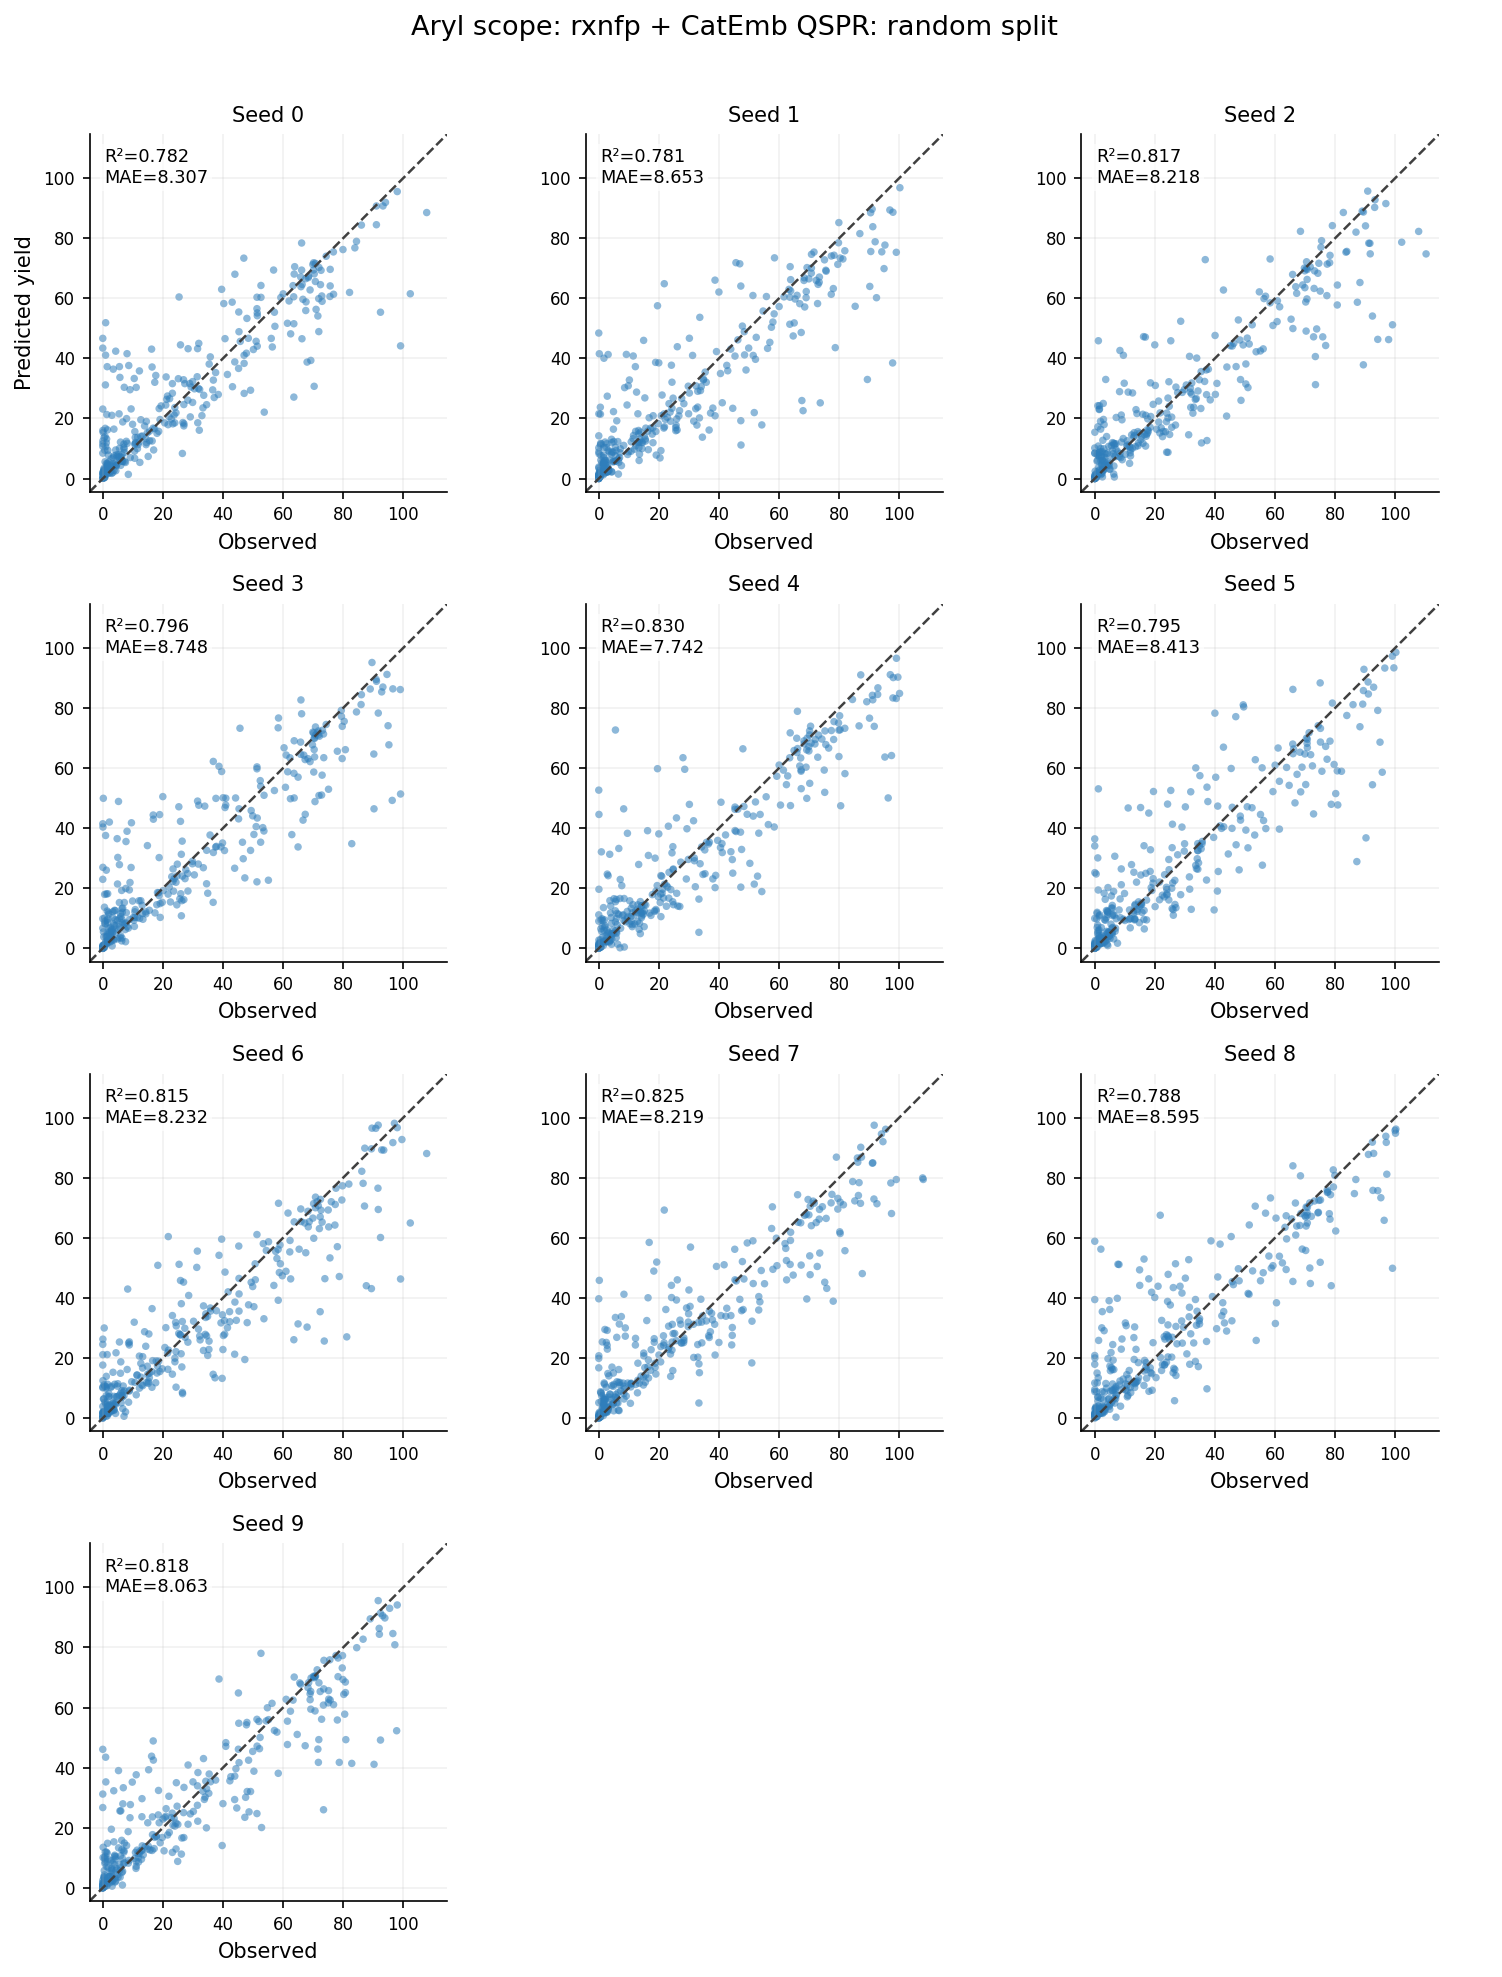

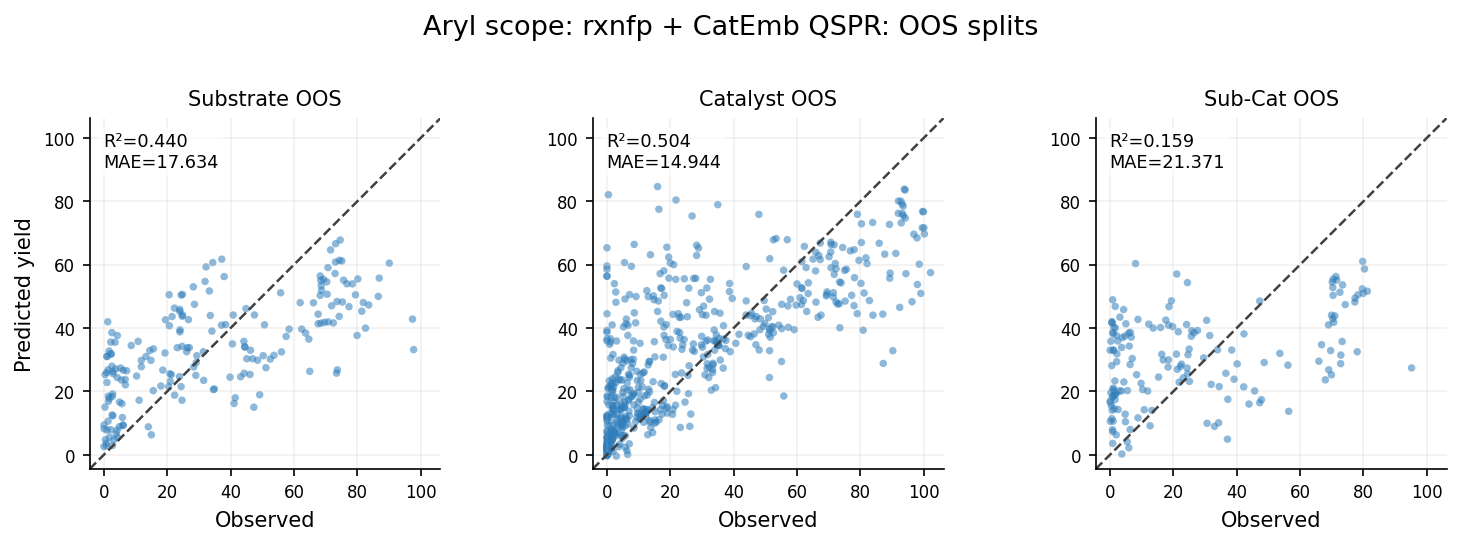

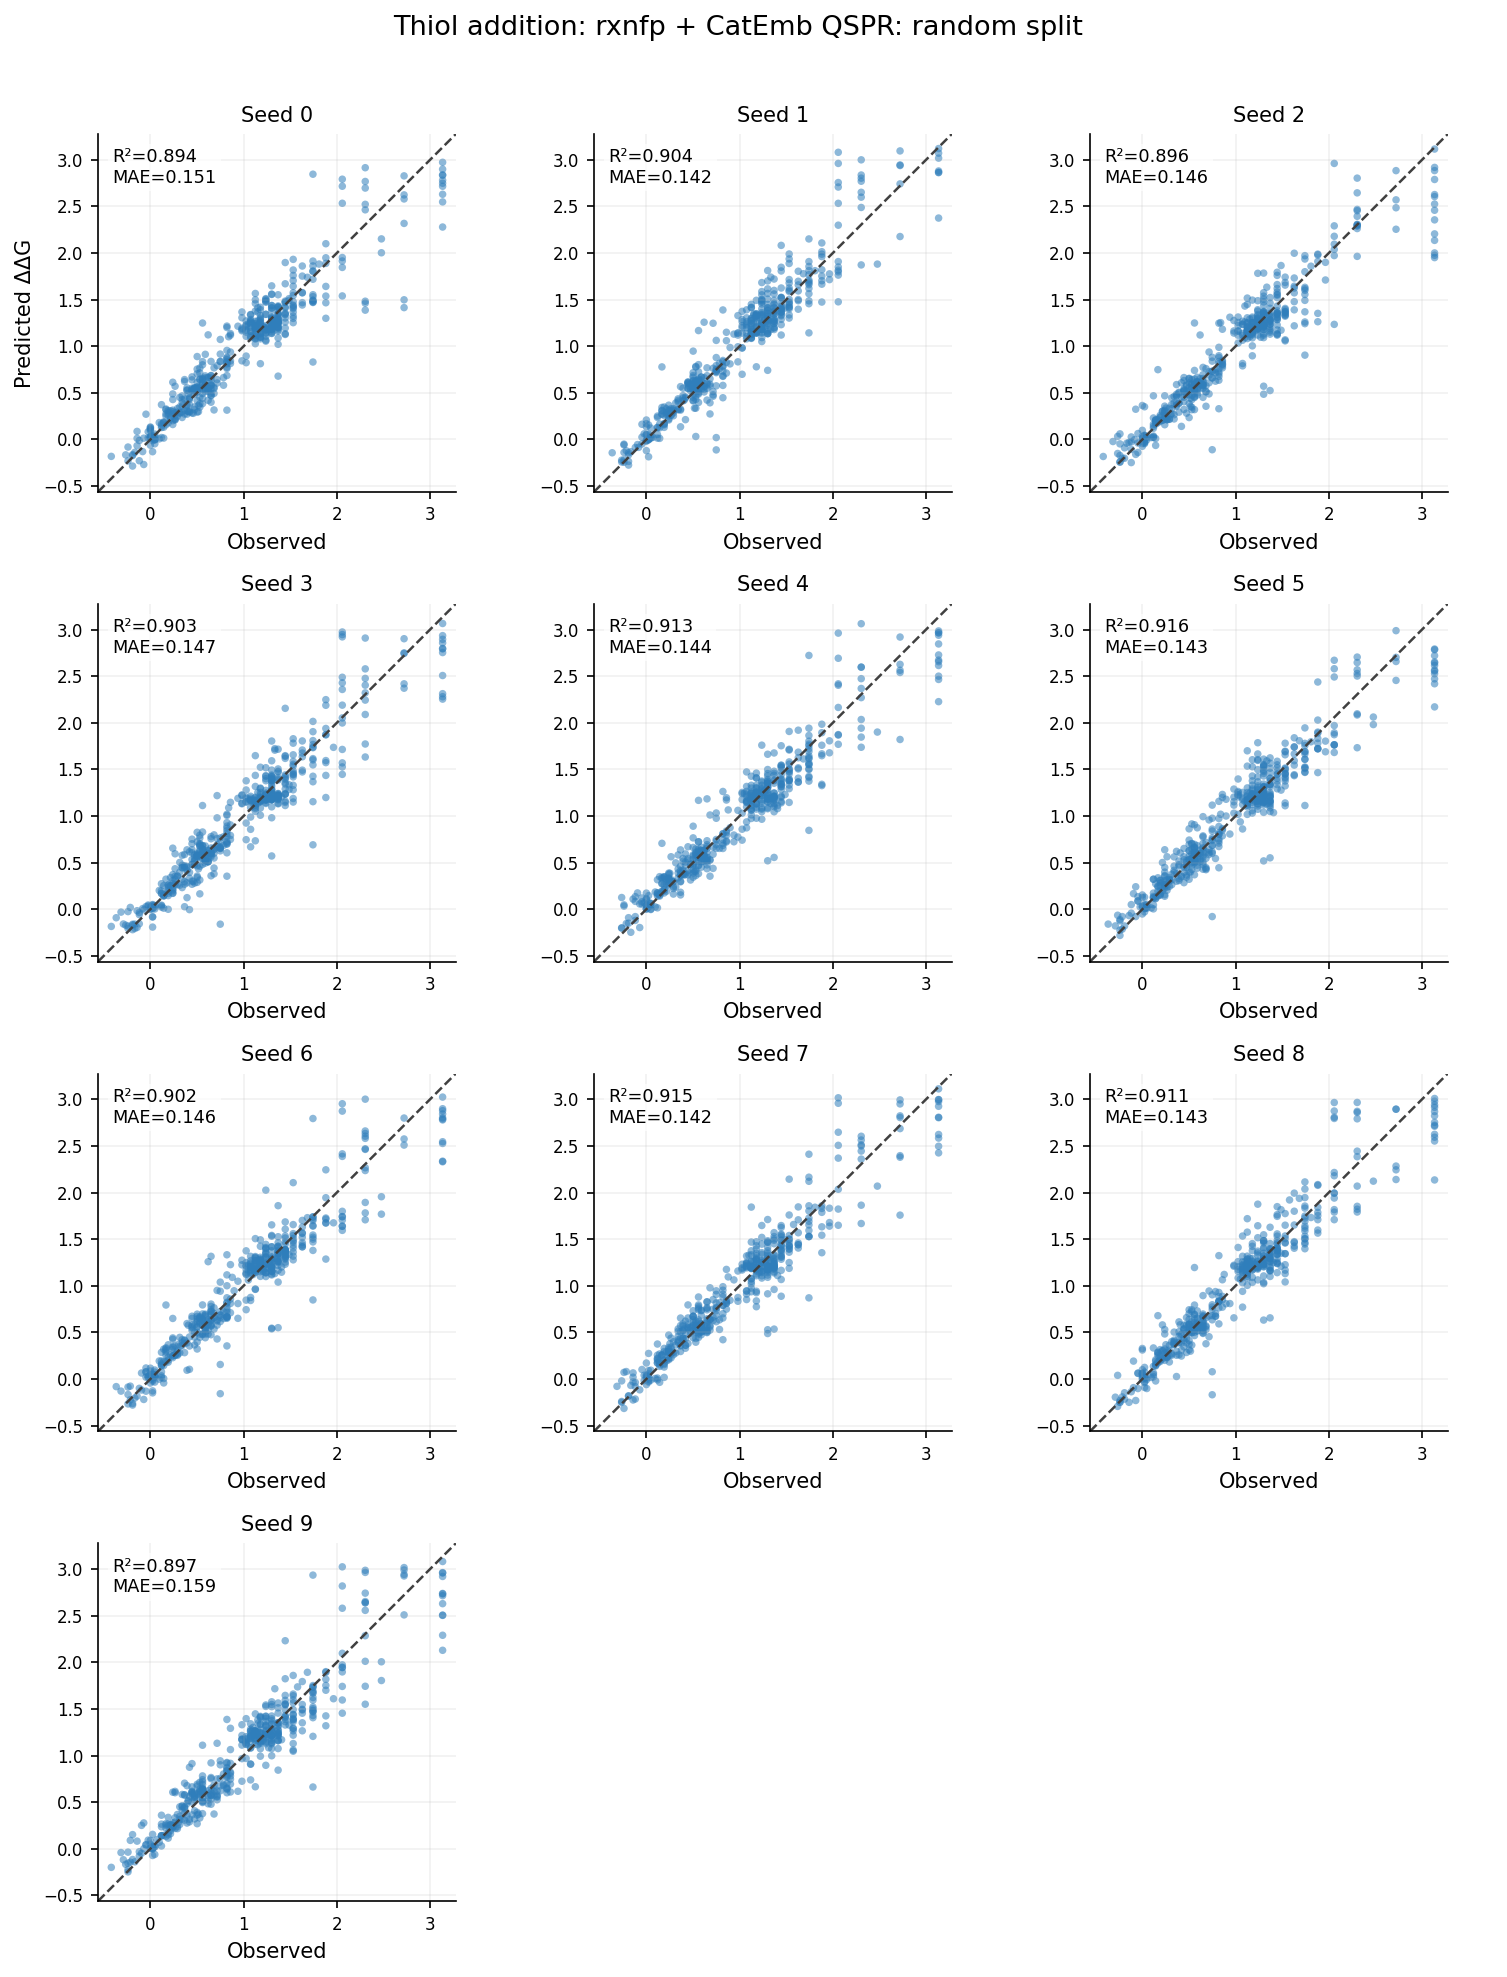

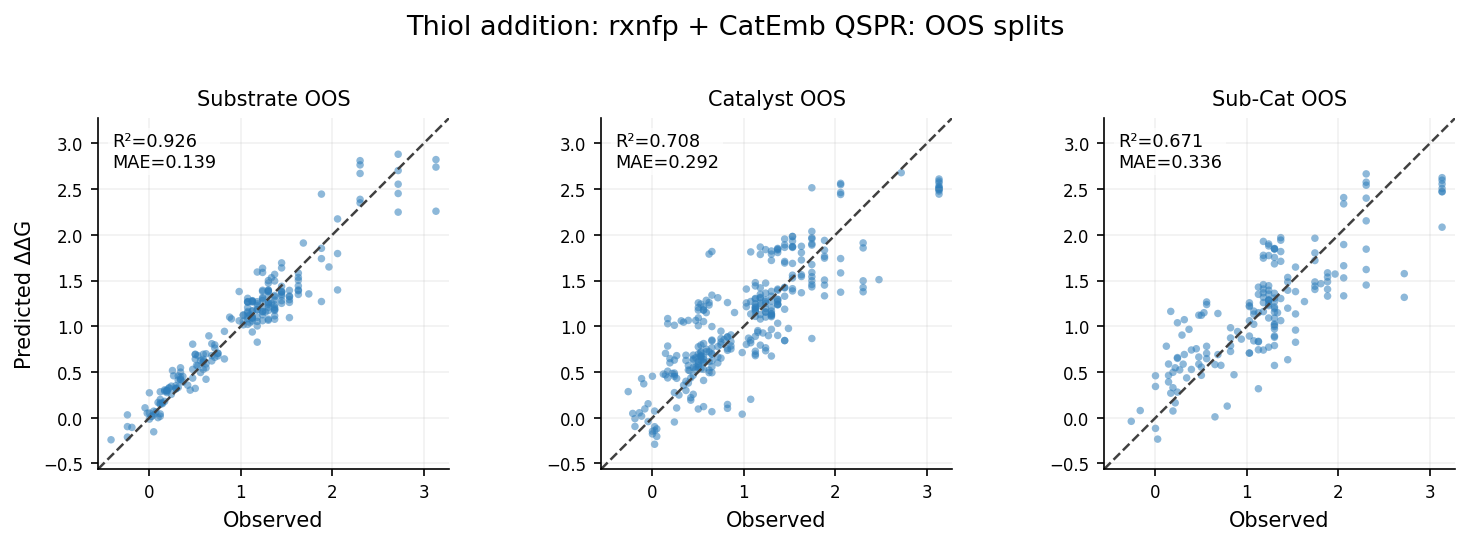

In [6]:
TASK_LABELS = {
    "random_split": "Random split",
    "substrate_oos": "Substrate OOS",
    "catalyst_oos": "Catalyst OOS",
    "substrate_catalyst_oos": "Sub-Cat OOS",
}
OOS_TASK_ORDER = ["substrate_oos", "catalyst_oos", "substrate_catalyst_oos"]


def panel_limits(pred_df):
    lo = min(pred_df["y_true"].min(), pred_df["y_pred"].min())
    hi = max(pred_df["y_true"].max(), pred_df["y_pred"].max())
    pad = 0.04 * (hi - lo) if hi > lo else 1.0
    return lo - pad, hi + pad


def style_scatter_axis(ax, sub, title, ylabel=None, metric_text=None, limits=None):
    color = "#2F7EBB"
    ax.scatter(sub["y_true"], sub["y_pred"], s=13, alpha=0.55, color=color, edgecolor="none")
    lo, hi = limits if limits is not None else panel_limits(sub)
    ax.plot([lo, hi], [lo, hi], color="0.25", lw=1.2, ls="--")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=10)
    if metric_text is not None:
        ax.text(
            0.04, 0.96,
            metric_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
        )
    ax.set_xlabel("Observed", fontsize=10)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.18, linewidth=0.8)


def plot_random_seed_scatter(pred_df, dataset_title, ylabel, output_path, n_cols=3):
    sub_all = pred_df[pred_df["task"].eq("random_split")].copy()
    seeds = sorted(sub_all["seed"].dropna().astype(int).unique())
    n_rows = int(np.ceil(len(seeds) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.45 * n_cols, 3.25 * n_rows), dpi=150)
    axes = np.asarray(axes).reshape(-1)
    limits = panel_limits(sub_all)
    for ax, seed in zip(axes, seeds):
        sub = sub_all[sub_all["seed"].astype(int).eq(seed)]
        m = metrics(sub["y_true"].to_numpy(), sub["y_pred"].to_numpy())
        style_scatter_axis(
            ax,
            sub,
            f"Seed {seed}",
            ylabel=f"Predicted {ylabel}" if ax is axes[0] else None,
            metric_text=f"R²={m['r2']:.3f}\nMAE={m['mae']:.3f}",
            limits=limits,
        )
    for ax in axes[len(seeds):]:
        ax.axis("off")
    fig.suptitle(f"{dataset_title}: random split", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_oos_scatter(pred_df, metric_df, dataset_title, ylabel, output_path):
    fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.35), dpi=150)
    oos_pred = pred_df[pred_df["task"].isin(OOS_TASK_ORDER)]
    limits = panel_limits(oos_pred)
    for ax, task in zip(axes, OOS_TASK_ORDER):
        sub = pred_df[pred_df["task"].eq(task)]
        m = metric_df[metric_df["task"].eq(task)].iloc[0]
        style_scatter_axis(
            ax,
            sub,
            TASK_LABELS[task],
            ylabel=f"Predicted {ylabel}" if ax is axes[0] else None,
            metric_text=f"R²={m['r2']:.3f}\nMAE={m['mae']:.3f}",
            limits=limits,
        )
    fig.suptitle(f"{dataset_title}: OOS splits", fontsize=13, y=1.04)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_random_seed_scatter(
    aryl_pred_df,
    "Aryl scope: rxnfp + CatEmb QSPR",
    "yield",
    RESULT_DIR / "aryl_scope_rxnfp_catemb_random_split_seed_scatter.png",
)
plot_oos_scatter(
    aryl_pred_df,
    aryl_metric_df,
    "Aryl scope: rxnfp + CatEmb QSPR",
    "yield",
    RESULT_DIR / "aryl_scope_rxnfp_catemb_oos_scatter.png",
)
plot_random_seed_scatter(
    thiol_pred_df,
    "Thiol addition: rxnfp + CatEmb QSPR",
    "ΔΔG",
    RESULT_DIR / "thiol_addition_rxnfp_catemb_random_split_seed_scatter.png",
)
plot_oos_scatter(
    thiol_pred_df,
    thiol_metric_df,
    "Thiol addition: rxnfp + CatEmb QSPR",
    "ΔΔG",
    RESULT_DIR / "thiol_addition_rxnfp_catemb_oos_scatter.png",
)